In [44]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch, torch.nn as nn
from torch.optim import Adam
from torchsummary import summary
from torch.optim.lr_scheduler import StepLR
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Vai fazer uma verificacao se o cuda ta disponivel
# se sim, usa, senao, usa cpu
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [80]:
# Data augmentation para os dados de treino
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    # Media e Std para CIFAR-100
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

# Data augmentation para os dados de teste
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

In [81]:
# Carrega o dataset
train_raw = datasets.CIFAR100('/content', download=True, train=True, transform=train_transform)
val_raw = datasets.CIFAR100('/content', download=True, train=False, transform=val_transform)

In [82]:
train_ds = DataLoader(train_raw, 256, True)
val_ds = DataLoader(val_raw, 256)

In [ ]:
# Era o mesmo modelo, eu tive que alterar umas coisas
# Basicamente adicionei o BatchNorm2d e o Dropout, e mudei a quantidade de filtros
def get_model():
    model = nn.Sequential(
        nn.Conv2d(3, 128, 3),
        nn.BatchNorm2d(128),
        nn.MaxPool2d(2),
        nn.ReLU(),
        nn.Conv2d(128, 256, 3),
        nn.BatchNorm2d(256),
        nn.MaxPool2d(2),
        nn.ReLU(),
        nn.Conv2d(256, 512, 3),
        nn.BatchNorm2d(512),
        nn.MaxPool2d(2),
        nn.ReLU(),
        nn.Flatten(),
        nn.Dropout(0.4),
        nn.Linear(512*2*2, 256),
        nn.ReLU(),
        nn.Linear(256, 100)
    ).to(device)
    loss_fn = nn.CrossEntropyLoss()
    # Coloquei weight_decay para regularização L2
    # Para reduzir o overfitting e tx e aprendizagem de 0.001 para
    # melhorar a convergencia
    optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=3e-4)
    return model, loss_fn, optimizer

In [ ]:
# Treina o modelo em um batch de dados
# data e labels são os dados e rotulos do batch
# criterion e a func de perda, optimizer e o otimizador
# model e o modelo que to treinando
def train_batch(data, labels, model, criterion, optimizer):
  model.train()
  # precisa colocar os dados e labels no device, senao da erro
  data, labels = data.to(device), labels.to(device)
  # zera os gradientes do otimizador
  # faz o forward pass do modelo e calcula a perda
  optimizer.zero_grad()
  output = model(data)
  loss = criterion(output, labels)
  loss.backward()
  optimizer.step()
  return loss

In [ ]:
# valida o modelo em um batch de dados
@torch.no_grad()
def validate_batch(data, labels, model, criterion):
  # vai avaliar o modelo tirando o dropout e o batchnorm
  model.eval()
  data, labels = data.to(device), labels.to(device)
  output = model(data)
  loss = criterion(output, labels)
  return loss

In [ ]:
# calcula a acuracia do modelo tbm em um batch dados, feito para toda epoca
@torch.no_grad()
def accuracy(data, labels, model):
  data, labels = data.to(device), labels.to(device)
  prediction = model(data)
  max_values, argmaxes = prediction.max(-1)
  is_correct = argmaxes == labels
  return is_correct.cpu().numpy().tolist()

In [ ]:
model, loss_fn, optimizer = get_model()
# Coloquei o StepLR pra reduzir a tx de aprendizagem a cada 15 epocas
# multiplica por .5 que vai diminuir a tx pela metade
scheduler = StepLR(optimizer, step_size=15, gamma=0.5)
# arquitetura do modelo, input de 3 canais e 32x32 de tamanho,10
summary(model, (3,32,32));

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 128, 30, 30]           3,584
       BatchNorm2d-2          [-1, 128, 30, 30]             256
         MaxPool2d-3          [-1, 128, 15, 15]               0
              ReLU-4          [-1, 128, 15, 15]               0
            Conv2d-5          [-1, 256, 13, 13]         295,168
       BatchNorm2d-6          [-1, 256, 13, 13]             512
         MaxPool2d-7            [-1, 256, 6, 6]               0
              ReLU-8            [-1, 256, 6, 6]               0
            Conv2d-9            [-1, 512, 4, 4]       1,180,160
      BatchNorm2d-10            [-1, 512, 4, 4]           1,024
        MaxPool2d-11            [-1, 512, 2, 2]               0
             ReLU-12            [-1, 512, 2, 2]               0
          Flatten-13                 [-1, 2048]               0
          Dropout-14                 [-

In [ ]:
num_epochs = 45
best_acc = 0

# Inicio do treinamento
# vai treinar o modelo por 45 epocas
# para cada epoca vai calcular a perda e acuracia de treino e validacao
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(num_epochs):
    epoch_trn_loss, epoch_trn_acc = [], []
    for data, label in train_ds: # para cada batch de dados e rotulos do dataset de treino
        loss = train_batch(data, label, model, loss_fn, optimizer) # treina o modelo com o batch atual
        epoch_trn_loss.append(loss.item()) # adiciona a perda do batch atual na lista de perdas da epoca
        is_correct = accuracy(data, label, model)# verifica se o modelo acertou ou errou a classificacao do batch atual
        epoch_trn_acc.extend(is_correct) # adiciona os resultados do batch atual na lista de acuracias da epoca

    epoch_val_loss, epoch_val_acc = [], []
    for data, label in val_ds: # para cada batch de dados e rotulos do dataset de validacao
        loss = validate_batch(data, label, model, loss_fn) # valida o modelo com o batch atual
        epoch_val_loss.append(loss.item()) # adiciona a perda do batch atual na lista de perdas da epoca
        is_correct = accuracy(data, label, model)# verifica se o modelo acertou ou errou a classificacao do batch atual
        epoch_val_acc.extend(is_correct)# adiciona os resultados do batch atual na lsita de acuracias da epoca

    train_losses.append(np.mean(epoch_trn_loss)) # adiciona a media das perdas da epoca na lista de perdas de treino
    train_accuracies.append(np.mean(epoch_trn_acc)) # adiciona a media das acuracias da epoca na lista de acuracias de treino
    val_losses.append(np.mean(epoch_val_loss)) # adiciona a media das perdas da epoca na lista de perdas de validacao
    val_accuracies.append(np.mean(epoch_val_acc))# adiciona a media das acuracias da epoca na lista de acuracias de validacao
    # para cada epoca, se a acuracia de validacao for maior que a melhor acuracia ate agora, salva o modelo
    # para nao correr o risco do modelo anterior ter sido melhor que o atual e perder ele
    if val_accuracies[-1] > best_acc:
          best_acc = val_accuracies[-1]
          torch.save(model.state_dict(), 'best_model.pth')
    scheduler.step()

    # printa a epoca atual, perda de treino, perda de validacao e acuracia de validacao
    print(f"epoch {epoch+1}: trn_loss={train_losses[-1]:.3f} val_loss={val_losses[-1]:.3f} val_acc={val_accuracies[-1]:.3f}")

epoch 1: trn_loss=3.606 val_loss=3.035 val_acc=0.246
epoch 2: trn_loss=2.901 val_loss=2.602 val_acc=0.331
epoch 3: trn_loss=2.615 val_loss=2.449 val_acc=0.363
epoch 4: trn_loss=2.425 val_loss=2.216 val_acc=0.417
epoch 5: trn_loss=2.301 val_loss=2.106 val_acc=0.442
epoch 6: trn_loss=2.212 val_loss=2.033 val_acc=0.455
epoch 7: trn_loss=2.128 val_loss=2.067 val_acc=0.457
epoch 8: trn_loss=2.048 val_loss=1.911 val_acc=0.485
epoch 9: trn_loss=1.995 val_loss=1.884 val_acc=0.501
epoch 10: trn_loss=1.939 val_loss=1.793 val_acc=0.519
epoch 11: trn_loss=1.889 val_loss=1.814 val_acc=0.509
epoch 12: trn_loss=1.840 val_loss=1.787 val_acc=0.516
epoch 13: trn_loss=1.806 val_loss=1.730 val_acc=0.531
epoch 14: trn_loss=1.768 val_loss=1.717 val_acc=0.534
epoch 15: trn_loss=1.737 val_loss=1.674 val_acc=0.541
epoch 16: trn_loss=1.578 val_loss=1.550 val_acc=0.573
epoch 17: trn_loss=1.538 val_loss=1.550 val_acc=0.577
epoch 18: trn_loss=1.502 val_loss=1.506 val_acc=0.584
epoch 19: trn_loss=1.478 val_loss=1.5

In [ ]:
# vai avaliar o modelo tirando o dropout e o batchnorm
model.eval()
latent_vectors = []
classes = []

with torch.no_grad():
    for im, clss in val_ds:# para cada batch de imagens e classes do dataset de validacao
        im = im.to(device) # coloca as imagens no device
        latent_vectors.append(model[:-1](im).view(len(im), -1))# adiciona os vetores latentes do modelo na lista de vetores latentes
        classes.extend(clss.tolist()) # adiciona as classes do batch atual na lista de classes
# concatena todos os vetores latentes em um único tensor e converte para numpy
latent_vectors = torch.cat(latent_vectors).cpu().numpy()
# faz o tsne para reduzir a dimensionalidade dos vetores latentes para 2D
tsne = TSNE(2)
clustered = tsne.fit_transform(latent_vectors)

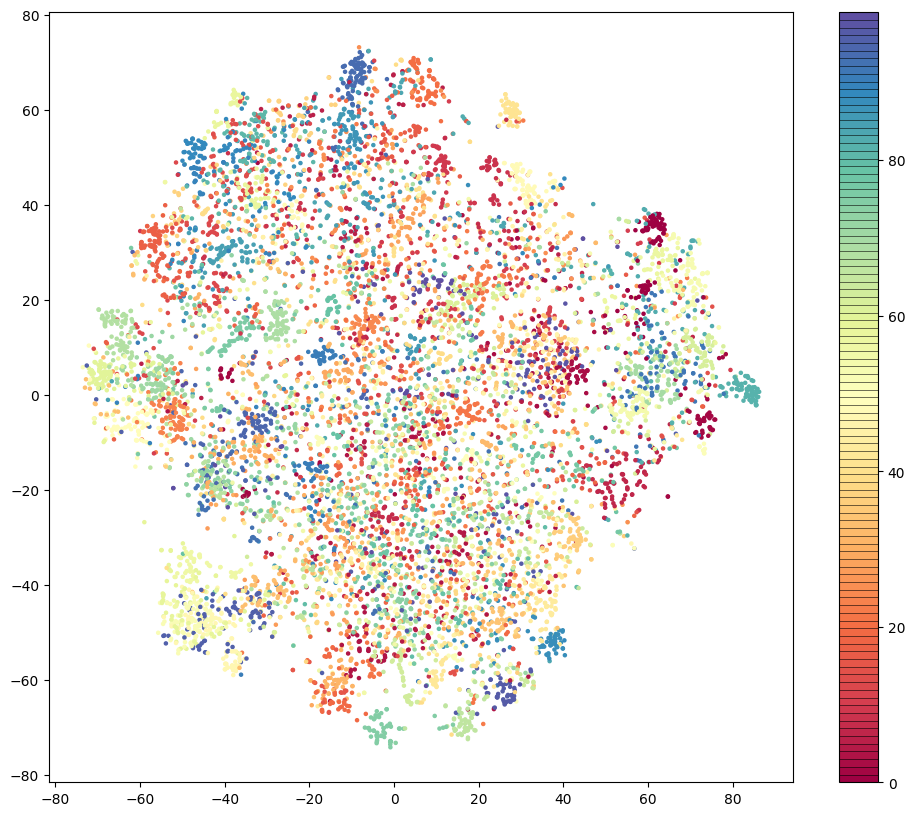

In [ ]:
# plota os vetores latentes em 2D com cores diferentes para cada classe
# vai mostrar como o modelo classificou as imagens, se ele conseguiu separar bem as classes ou nao
fig = plt.figure(figsize=(12,10))
cmap = plt.get_cmap('Spectral', 100)
plt.scatter(*zip(*clustered), c=classes, cmap=cmap, s=5)
plt.colorbar(drawedges=True)